In [2]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin


In [14]:
#参数
dela = 0.6
t = 1
af =0
a = 1
U = 0
mz = 0
mu = 0
hc=0#100
h =hc * np.sqrt(mu**2 + dela**2)
#0.5*np.sqrt(h**2 - dela**2)
#L = 11
chaodaojiao = 0
saimanjiao = 0#np.pi / 4

In [24]:
#参数
dela = 0.1875
t = 38*dela
af =4/dela
a = 1
U = 1.9*dela
mz = 7*dela
mu = 8*dela
hc=1.2#100
h =hc * np.sqrt(mu**2 + dela**2)
#0.5*np.sqrt(h**2 - dela**2)
#L = 11
chaodaojiao = 0
#saimanjiao = np.pi /2
saimanjiao = 0

In [25]:
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.eye(2, dtype=complex)

#左边矩阵信息
HL_block=-(mu-2*t)*s0 + h*np.cos(0)*sx + h*np.sin(0)*sy
Delta_L=dela * np.exp(1j*chaodaojiao/2) * 1j * sy
H_L_onsite=np.block([
        [ HL_block,        Delta_L        ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])
H_L_right_to_left_hop_block=-1*(t*s0+1j*af*sz/a)
H_L_right_to_left_hop=np.block([
        [ H_L_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_L_right_to_left_hop_block.conj() ]
    ])

#中间矩阵信息

H_center_to_L=np.block([
        [ -t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])
H_center_block=(U-mu+2*t)*s0+mz*sz
H_center=np.block([
        [ H_center_block,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , -H_center_block.conj()  ]
    ])
    
H_center_right_to_left_hop=np.block([
        [ -t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])
H_R_to_center=np.block([
        [ -t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])

#右边矩阵信息
HR_block=-(mu-2*t)*s0 + h*np.cos(saimanjiao)*sx + h*np.sin(saimanjiao)*sy
Delta_R=dela * np.exp(-1j*chaodaojiao/2) * 1j * sy
H_R_onsite=np.block([
        [ HR_block,        Delta_R        ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])
H_R_right_to_left_hop_block=-1*(t*s0+1j*af/a*sz)
H_R_right_to_left_hop=np.block([
        [ H_R_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_R_right_to_left_hop_block.conj() ]
    ])
H_q=H_center
T_12= H_center_right_to_left_hop.conj().T
H_l= H_L_onsite
T_l= H_L_right_to_left_hop
H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T
T_LD=H_center_to_L
T_RD= H_R_to_center
N=10
q=2

#E=0


In [28]:
def build_center_chain_A(N, H_q, T_12, E, eta=1e-6, Sigma_L=None, Sigma_R=None):
    """
    构造 (E + iη)I - H_big 的 BdG tight-binding 矩阵
    """

    dim = H_q.shape[0]   # 4
    H_big = np.zeros((dim*N, dim*N), dtype=complex)

    for i in range(N):
        # onsite
        H_big[i*dim:(i+1)*dim, i*dim:(i+1)*dim] = H_q.copy()

        # hopping
        if i < N - 1:
            H_big[i*dim:(i+1)*dim, (i+1)*dim:(i+2)*dim] = T_12
            H_big[(i+1)*dim:(i+2)*dim, i*dim:(i+1)*dim] = T_12.conj().T

    # self-energy
    if Sigma_L is not None:
        H_big[0:dim, 0:dim] += Sigma_L

    if Sigma_R is not None:
        H_big[-dim:, -dim:] += Sigma_R

    # Dyson matrix
    A = (E + 1j*eta) * np.eye(dim*N, dtype=complex) - H_big

    return A

In [19]:
def gr_L(T_l, A_l, check_tol=1e-6):
    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  


    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))
#    print(max_err)
    if max_err > check_tol:
        mag = np.abs(eigvals)
        print("Sorted |eigvals|:", np.sort(mag))
        raise RuntimeError(
            fr"Self-consistency violated: max |Δ| = {max_err}"
        )
    return gL
#检查
#A_l_1 = (0.4413231958425607+ 1j*1e-6) * np.eye(H_l.shape[0]) - H_l  
#gr_L(T_l, A_l_1)

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q,H_l,H_r,  T_12,T_LD,T_l,T_RD,T_r,  N,E,eta=1*1e-4):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    EI_gai=np.block([
        [ (E + 1j*eta)*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , 1*(E + 1j*eta)*s0 ]
    ])
    A_l = EI_gai - H_l 
    gcl=gr_L(T_l, A_l)              
    Sigma_L = zinengr_L(T_LD, gcl )     


    A_r = EI_gai- H_r
    gcr=gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    dim = N * d
    A_DD = np.zeros((dim, dim), dtype=complex)

    for i in range(N):
        if i == 0:
            Aii = EI_gai - H_q - Sigma_L
        elif i == N-1:
            Aii = EI_gai - H_q - Sigma_R
        else:
            Aii = EI_gai - H_q

        A_DD[i*d:(i+1)*d, i*d:(i+1)*d] = Aii

        if i < N-1:
            A_DD[i*d:(i+1)*d, (i+1)*d:(i+2)*d] = -T_12

        if i > 0:
            A_DD[i*d:(i+1)*d, (i-1)*d:i*d] = -T_12.conj().T

    G_DD_r = np.linalg.inv(A_DD)
    return G_DD_r , A_DD ,Sigma_R ,Sigma_L 

#检查
#E=0.4413231958425607
#_DD_r_1 , A_DD_1 ,Sigma_R_1 ,Sigma_L_1 =Gr_DD(H_q,H_l,H_r,  T_12,T_LD,T_l,T_RD,T_r,  N,E,eta=1e-6)

#A=build_center_chain_A(N, H_q, T_12, E, eta=1e-6, Sigma_L=Sigma_L_1, Sigma_R=Sigma_R_1)

#jiancha= G_DD_r_1 @ A
#print(np.linalg.det(jiancha))


def bufeng(G_DD_r):
    d = H_q.shape[0]
    yigeshu=np.trace(G_DD_r[q*d:(q+1)*d, (q)*d:(q+1)*d])
    return -np.imag(yigeshu)/np.pi

def find_peaks_fmin(A_of_E, E_min, E_max, N_guess=10, xtol=1e-6, ftol=1e-6, round_digits=6):

    E_guesses = np.linspace(E_min, E_max, N_guess)
    peak_list = []

    # 多初值 fmin 找最大值
    for E0 in E_guesses:
        r = fmin(lambda E: -A_of_E(E), E0, disp=False, xtol=xtol, ftol=ftol)
        peak_list.append(r[0])

    # 去重
    peak_list = np.unique(np.round(peak_list, round_digits))
    return peak_list


def G_DD_less_then(A_DD ,G_DD_r,zinengr_L_wei,zinengr_R_wei,E):  

    feimi1 = 1.0 /(3.5*dela*1e-6)
    feimi2 = 1.0 /(3.5*dela*1e-6)
    zineng_DD_less_then = np.zeros((H_q.shape[0]*N, H_q.shape[0]*N), dtype=complex)
    zineng_DD_less_then[0:4, 0:4]=-2j*(np.imag(zinengr_L_wei))*(1/(1+np.exp((E-mu) * feimi1)))
    zineng_DD_less_then[(N-1)*4:4*N, (N-1)*4:4*N]=-2j*(np.imag(zinengr_R_wei))*(1/(1+np.exp((E-mu) * feimi2)))

    G_DD_less_then_wei= G_DD_r @ zineng_DD_less_then @ G_DD_r.conj().T 
    return G_DD_less_then_wei


def J_integral(G_DD_less_then_wei,T_12,q):
    d= T_12.shape[0]
    J=T_12 @ G_DD_less_then_wei[(q+1)*d:(q+2)*d, (q)*d:(q+1)*d]- T_12.conj().T @ G_DD_less_then_wei[(q)*d:(q+1)*d, (q+1)*d:(q+2)*d]
    return (np.trace(J))/(2*np.pi)
def build_E_adapt(q, E_coarse, n_adapt=1000, alpha=0.7):
    J_coarse = J_vs_energy(E_coarse, q)
    dJ_dE = np.abs(np.gradient(J_coarse, E_coarse))

    w = dJ_dE**alpha
    w /= np.trapz(w, E_coarse)

    cdf = np.cumsum(w * np.gradient(E_coarse))
    cdf /= cdf[-1]

    u = np.linspace(0, 1, n_adapt)
    E_adapt = np.interp(u, cdf, E_coarse)

    return E_adapt
def current_energy_integral(E_set, q):
    Es = E_set

    I_E_list = []

    for E in Es:
        G_DD_r, A_DD, Sigma_R, Sigma_L = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, E
        )

        G_less = G_DD_less_then(
            A_DD, G_DD_r, Sigma_L, Sigma_R, E
        )

        I_E = J_integral(G_less, T_12, q)
        I_E_list.append(I_E)

    I_total = np.trapz(I_E_list, Es)

    return I_total




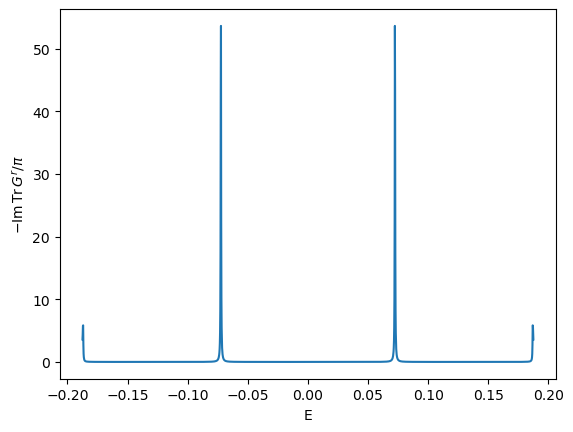

峰位置 E = [-0.18693722 -0.07231741  0.07231741  0.18693722]


In [60]:
E_set = np.linspace(-dela*1, dela*1, 2000)
A_E = []

for E in E_set:
    G_DD_r, _, _, _ = Gr_DD(
        H_q, H_l, H_r,
        T_12, T_LD, T_l, T_RD, T_r,
        N, E
    )
    A_E.append(bufeng(G_DD_r))

plt.plot(E_set, A_E)
plt.xlabel("E")
plt.ylabel(r"$-\mathrm{Im}\,\mathrm{Tr}\,G^r/\pi$")
plt.show()

A_E = np.array(A_E)
E_set = np.array(E_set)

threshold = 0.1
peak_indices = []

for i in range(1, len(A_E) - 1):
    if (A_E[i] - A_E[i-1] > threshold) and (A_E[i] - A_E[i+1] > threshold):
        peak_indices.append(i)

peak_energies = E_set[peak_indices]
peak_values = A_E[peak_indices]

print("峰位置 E =", peak_energies)


In [ ]:
import numpy as np


def A_of_E(E):
    E = float(np.atleast_1d(E)[0])
    G_DD_r, _, _, _ = Gr_DD(
        H_q, H_l, H_r,
        T_12, T_LD, T_l, T_RD, T_r,
        N, E
    )
    return bufeng(G_DD_r)

def neg_A_of_E(E):
    return -A_of_E(E)

E0 = 5
result =fmin(neg_A_of_E, E0, disp=False, xtol=1e-5, ftol=1e-5)
E_peak = result[0]
A_peak = A_of_E(E_peak)

print("峰值能量 E =", E_peak)
print("峰值 A(E) =", A_peak)

E_guesses = np.linspace(-dela, dela, 1000)
peak_list = []
for E0 in E_guesses:
    r = fmin(neg_A_of_E, E0, disp=False, xtol=1e-4, ftol=1e-4)
    peak_list.append(r[0])
peak_list = np.unique(np.round(peak_list, 4))
print("所有峰值 E =", peak_list,len(peak_list))


峰值能量 E = 1.8230133056640625
峰值 A(E) = 7.379461350852783
所有峰值 E = [-6.782e-01 -5.639e-01 -4.564e-01 -2.085e-01 -3.180e-02 -3.170e-02
 -6.000e-04  6.000e-04  3.170e-02  3.180e-02  2.085e-01  4.564e-01
  5.639e-01  6.782e-01] 14


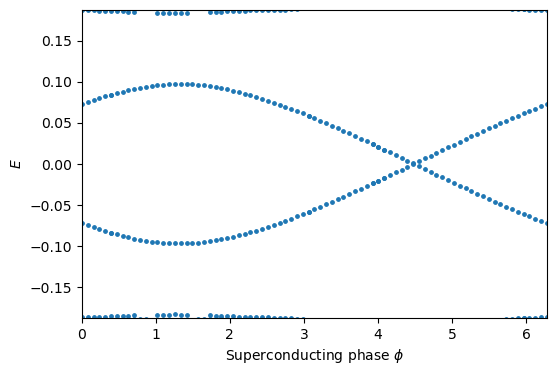

In [6]:
def find_peaks_fmin(A_of_E, E_min, E_max, N_guess=10, xtol=1e-6, ftol=1e-6, round_digits=6):
    E_guesses = np.linspace(E_min, E_max, N_guess)
    peak_list = []

    # 多初值 fmin 找最大值
    for E0 in E_guesses:
        r = fmin(lambda E: -A_of_E(E), E0, disp=False, xtol=xtol, ftol=ftol)
        peak_list.append(r[0])

    # 去重
    peak_list = np.unique(np.round(peak_list, round_digits))
    return peak_list
phi_set = np.linspace(0, 2*np.pi, 81)     # 超导相位
E_min, E_max = -dela, dela
phi_list = []
E_peak_list = []

for phi in phi_set:
    chaodaojiao = phi

    Delta_L = dela * np.exp(1j*chaodaojiao/2) * 1j * sy
    H_L_onsite = np.block([
        [ HL_block,          Delta_L ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])

    Delta_R = dela * np.exp(-1j*chaodaojiao/2) * 1j * sy
    H_R_onsite = np.block([
        [ HR_block,          Delta_R ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])


    H_l = H_L_onsite
    H_r = H_R_onsite

    def A_of_E(E):
        G_DD_r, _, _, _ = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, E
        )
        return bufeng(G_DD_r)


    peak_energies = find_peaks_fmin(A_of_E, E_min, E_max, N_guess=10, xtol=1e-6, ftol=1e-6)


    for E_peak in peak_energies:
        phi_list.append(phi)
        E_peak_list.append(E_peak)


plt.figure(figsize=(6,4))
plt.scatter(phi_list, E_peak_list, s=6)
plt.xlabel(r"Superconducting phase $\phi$")
plt.ylabel(r"$E$")
plt.xlim(0, 2*np.pi)
#plt.ylim(E_min, E_max)
plt.ylim(E_min, E_max)
plt.show()


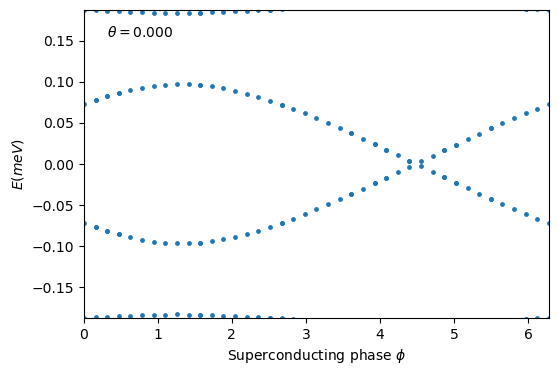

In [36]:
def find_peaks_fmin(A_of_E, E_min, E_max, N_guess=10, xtol=1e-6, ftol=1e-6, round_digits=6):

    E_guesses = np.linspace(E_min, E_max, N_guess)
    peak_list = []

    # 多初值 fmin 找最大值
    for E0 in E_guesses:
        r = fmin(lambda E: -A_of_E(E), E0, disp=False, xtol=xtol, ftol=ftol)
        peak_list.append(r[0])

    # 去重
    peak_list = np.unique(np.round(peak_list, round_digits))
    return peak_list
saimanjiao = 0
phi_set = np.linspace(0, 4*np.pi, 81)     # 超导相位
E_min, E_max = -dela, dela
phi_list = []
E_peak_list = []

saimanjiao = 0

for phi in phi_set:
    chaodaojiao = phi

    Delta_L = dela * np.exp(1j*chaodaojiao/2) * 1j * sy
    H_L_onsite = np.block([
        [ HL_block,          Delta_L ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])

    HR_block=-(mu-2*t)*s0 + h*np.cos(saimanjiao)*sx + h*np.sin(saimanjiao)*sy
    Delta_R = dela * np.exp(-1j*chaodaojiao/2) * 1j * sy
    H_R_onsite = np.block([
        [ HR_block,          Delta_R ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])


    H_l = H_L_onsite
    H_r = H_R_onsite

    def A_of_E(E):
        G_DD_r, _, _, _ = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, E
        )
        return bufeng(G_DD_r)


    peak_energies = find_peaks_fmin(A_of_E, E_min, E_max, N_guess=10, xtol=1e-6, ftol=1e-6)


    for E_peak in peak_energies:
        phi_list.append(phi)
        E_peak_list.append(E_peak)


plt.figure(figsize=(6,4))
plt.scatter(phi_list, E_peak_list, s=6)

plt.xlabel(r"Superconducting phase $\phi$")
plt.ylabel(r"$E(meV)$")   #\Delta

plt.xlim(0, 2*np.pi)
plt.ylim(E_min, E_max)

plt.text(
    0.05, 0.95,
    rf"$\theta = {saimanjiao:.3f}$",
    transform=plt.gca().transAxes,
    verticalalignment='top'
)

plt.show()



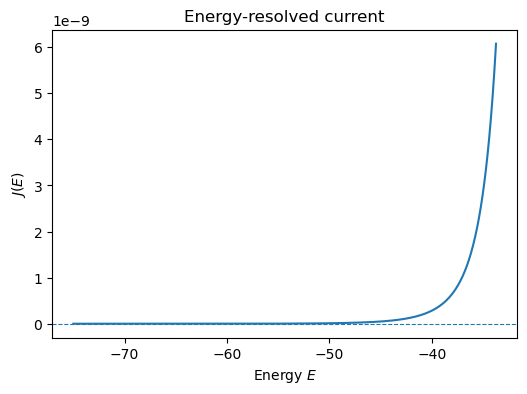

C:\Users\taoji\AppData\Local\Temp\ipykernel_34208\4245629758.py:114: RuntimeWarning: overflow encountered in exp
  zineng_DD_less_then[0:4, 0:4]=-2j*(np.imag(zinengr_L_wei))*(1/(1+np.exp((E-mu) * feimi1)))
C:\Users\taoji\AppData\Local\Temp\ipykernel_34208\4245629758.py:115: RuntimeWarning: overflow encountered in exp
  zineng_DD_less_then[(N-1)*4:4*N, (N-1)*4:4*N]=-2j*(np.imag(zinengr_R_wei))*(1/(1+np.exp((E-mu) * feimi2)))


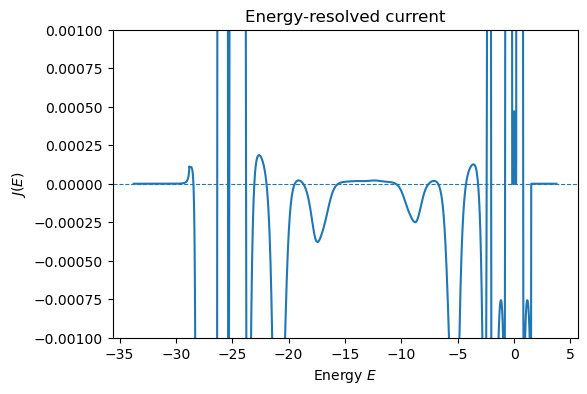

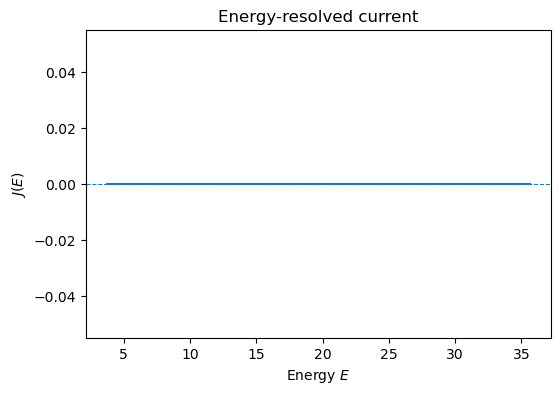

In [27]:
def J_vs_energy(E_set, q):
    J_E = []

    for E in E_set:
        G_DD_r, A_DD, Sigma_R, Sigma_L = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, E
        )

        G_less = G_DD_less_then(A_DD, G_DD_r, Sigma_L, Sigma_R, E)


        J_E.append(J_integral(G_less, T_12, q))

    return np.array(J_E)

E_set = np.linspace(-400*dela, -180*dela, 1000)

J_E = J_vs_energy(E_set, q)

plt.figure(figsize=(6,4))
plt.plot(E_set, J_E)
plt.axhline(0, ls='--', lw=0.8)
plt.xlabel(r"Energy $E$")
plt.ylabel(r"$J(E)$")
plt.title(r"Energy-resolved current")
plt.show()

E_set = np.linspace(-180*dela, 20*dela, 4000)

J_E = J_vs_energy(E_set, q)

plt.figure(figsize=(6,4))
plt.plot(E_set, J_E)
plt.axhline(0, ls='--', lw=0.8)
plt.xlabel(r"Energy $E$")
plt.ylabel(r"$J(E)$")
plt.title(r"Energy-resolved current")
plt.ylim(-0.001,0.001)
plt.show()

E_set = np.linspace(20*dela, 190*dela, 1000)

J_E = J_vs_energy(E_set, q)

plt.figure(figsize=(6,4))
plt.plot(E_set, J_E)
plt.axhline(0, ls='--', lw=0.8)
plt.xlabel(r"Energy $E$")
plt.ylabel(r"$J(E)$")
plt.title(r"Energy-resolved current")
plt.show()

C:\Users\taoji\AppData\Local\Temp\ipykernel_34208\4245629758.py:114: RuntimeWarning: overflow encountered in exp
  zineng_DD_less_then[0:4, 0:4]=-2j*(np.imag(zinengr_L_wei))*(1/(1+np.exp((E-mu) * feimi1)))
C:\Users\taoji\AppData\Local\Temp\ipykernel_34208\4245629758.py:115: RuntimeWarning: overflow encountered in exp
  zineng_DD_less_then[(N-1)*4:4*N, (N-1)*4:4*N]=-2j*(np.imag(zinengr_R_wei))*(1/(1+np.exp((E-mu) * feimi2)))


1000


(-35.8125, 9.5625)

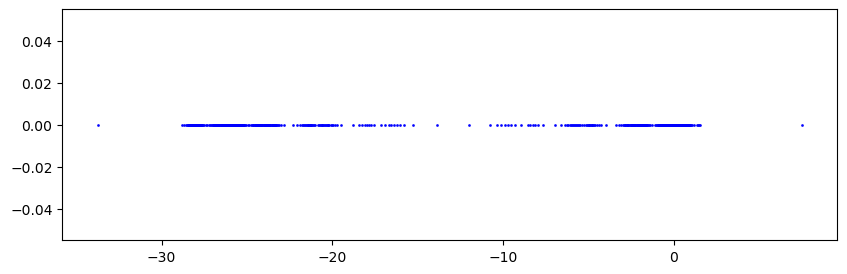

In [29]:
def J_vs_energy(E_set, q):
    J_E = []
    for E in E_set:
        G_DD_r, A_DD, Sigma_R, Sigma_L = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, E
        )
        G_less = G_DD_less_then(A_DD, G_DD_r, Sigma_L, Sigma_R, E)
        J_E.append(J_integral(G_less, T_12, q))
    return np.array(J_E)
E_coarse = np.linspace(-180*dela, 40*dela, 4000)
J_coarse = J_vs_energy(E_coarse, q)
dJ_dE = np.abs(np.gradient(J_coarse, E_coarse))
#print(dJ_dE)
alpha = 0.7
w = dJ_dE**alpha
w /= np.trapz(w, E_coarse)
cdf = np.cumsum(w * np.gradient(E_coarse))
cdf /= cdf[-1]

u = np.linspace(0, 1, 1000)
E_adapt = np.interp(u, cdf, E_coarse)

print(len(E_adapt))
y = np.zeros_like(E_adapt)
plt.figure(figsize=(10, 3))
plt.scatter(E_adapt, y, s=1,  c='blue', alpha=0.9)
plt.xlim()


In [ ]:
def build_E_adapt(q, E_coarse, n_adapt=3000, alpha=0.7):
    J_coarse = J_vs_energy(E_coarse, q)
    dJ_dE = np.abs(np.gradient(J_coarse, E_coarse))

    w = dJ_dE**alpha
    w /= np.trapz(w, E_coarse)

    cdf = np.cumsum(w * np.gradient(E_coarse))
    cdf /= cdf[-1]

    u = np.linspace(0, 1, n_adapt)
    E_adapt = np.interp(u, cdf, E_coarse)

    return E_adapt

phi_set = np.linspace(0, 2*np.pi, 11)
E_coarse = np.linspace(-180*dela, 20*dela, 3000)

I_phi = []

for phi in phi_set:
    chaodaojiao = phi


    Delta_L = dela * np.exp(1j*chaodaojiao/2) * 1j * sy
    Delta_R = dela * np.exp(-1j*chaodaojiao/2) * 1j * sy

    H_L_onsite = np.block([
        [ HL_block,              Delta_L ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])

    H_R_onsite = np.block([
        [ HR_block,              Delta_R ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])

    H_l = H_L_onsite
    H_r = H_R_onsite

    E_adapt = build_E_adapt(q, E_coarse)

    # --- 用自适应能量积分 ---
    I = current_energy_integral(E_adapt, q)
    I_phi.append(I)

I_phi = np.array(I_phi)
plt.figure(figsize=(6,4))
plt.plot(phi_set, I_phi, 'o-')
plt.xlabel(r"Superconducting phase $\phi$")
plt.ylabel(r"$I$")
plt.show()



C:\Users\taoji\AppData\Local\Temp\ipykernel_34208\4245629758.py:114: RuntimeWarning: overflow encountered in exp
  zineng_DD_less_then[0:4, 0:4]=-2j*(np.imag(zinengr_L_wei))*(1/(1+np.exp((E-mu) * feimi1)))
C:\Users\taoji\AppData\Local\Temp\ipykernel_34208\4245629758.py:115: RuntimeWarning: overflow encountered in exp
  zineng_DD_less_then[(N-1)*4:4*N, (N-1)*4:4*N]=-2j*(np.imag(zinengr_R_wei))*(1/(1+np.exp((E-mu) * feimi2)))


Sorted |eigvals|: [0.97228672 0.98076715 0.99566725 0.99566725 1.00435161 1.00435161
 1.01961001 1.0285032 ]


RuntimeError: Self-consistency violated: max |Δ| = 1.186128406623649e-06

: 

C:\Users\taoji\AppData\Local\Temp\ipykernel_28752\3007574909.py:122: RuntimeWarning: overflow encountered in exp
  zineng_DD_less_then[0:4, 0:4]=-2j*(np.imag(zinengr_L_wei))*(1/(1+np.exp((E-mu) * feimi1)))
C:\Users\taoji\AppData\Local\Temp\ipykernel_28752\3007574909.py:123: RuntimeWarning: overflow encountered in exp
  zineng_DD_less_then[(N-1)*4:4*N, (N-1)*4:4*N]=-2j*(np.imag(zinengr_R_wei))*(1/(1+np.exp((E-mu) * feimi2)))


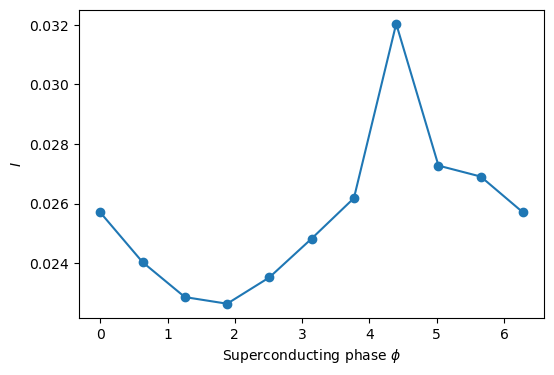

In [54]:
E_near = np.linspace(-25*dela, 250*dela, 1000)      # 近能区（用于构造 adapt）
E_far  = np.linspace(-180*dela, -25*dela, 1000)  # 远负能连续谱
phi_set = np.linspace(0, 2*np.pi, 11)
I_phi = []

def build_E_adapt(q, E_coarse, n_adapt=5000, alpha=0.7):
    J_coarse = J_vs_energy(E_coarse, q)
    dJ_dE = np.abs(np.gradient(J_coarse, E_coarse))

    w = dJ_dE**alpha
    w /= np.trapz(w, E_coarse)

    cdf = np.cumsum(w * np.gradient(E_coarse))
    cdf /= cdf[-1]

    u = np.linspace(0, 1, n_adapt)
    E_adapt = np.interp(u, cdf, E_coarse)

    return E_adapt
    
for phi in phi_set:
    chaodaojiao = phi


    Delta_L = dela * np.exp(1j*chaodaojiao/2) * 1j * sy
    Delta_R = dela * np.exp(-1j*chaodaojiao/2) * 1j * sy

    H_L_onsite = np.block([
        [ HL_block,              Delta_L ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])

    H_R_onsite = np.block([
        [ HR_block,              Delta_R ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])

    H_l = H_L_onsite
    H_r = H_R_onsite

    
    E_adapt = build_E_adapt(q, E_near)
    I_near = current_energy_integral(E_adapt, q)


    E_adapt_2 = build_E_adapt(q, E_far)
    I_far = current_energy_integral(E_adapt_2 , q)


    I_phi.append(I_near + I_far)

I_phi = np.array(I_phi)
plt.figure(figsize=(6,4))
plt.plot(phi_set, I_phi, 'o-')
plt.xlabel(r"Superconducting phase $\phi$")
plt.ylabel(r"$I$")
plt.show()
